In [1]:
import numpy as np
import matplotlib.pyplot as plt

from matplotlib.gridspec import GridSpec

from minisom import MiniSom

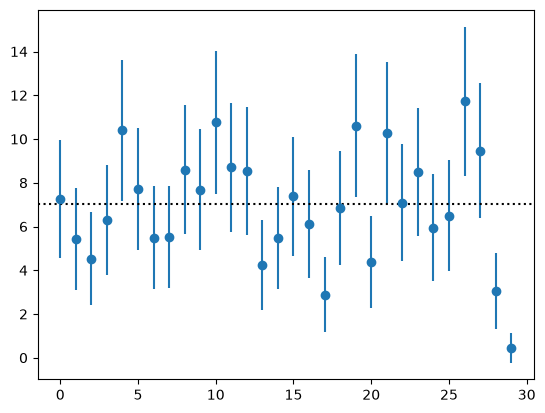

In [2]:
# Generate two sets of time series data with errors modeled after a possion distributions
# appropriate for count data. The first set of time series will be constant, while the second set will have underlying red noise.
rng = np.random.default_rng(42)
n_steps = 30

# Constant time series
n_constant_timeseries = 1000
mean_values = rng.uniform(low=0, high=10, size=n_constant_timeseries)
sigmas = np.sqrt(mean_values)
x_const = rng.normal(loc=mean_values, scale=sigmas, size=(30, n_constant_timeseries)).T
x_const_err = np.sqrt(abs(x_const))

i = rng.integers(low=0, high=n_constant_timeseries)
plt.errorbar(np.arange(n_steps), x_const[i], yerr=x_const_err[i], fmt='o')
plt.axhline(mean_values[i], color="k", ls=":")
plt.show()

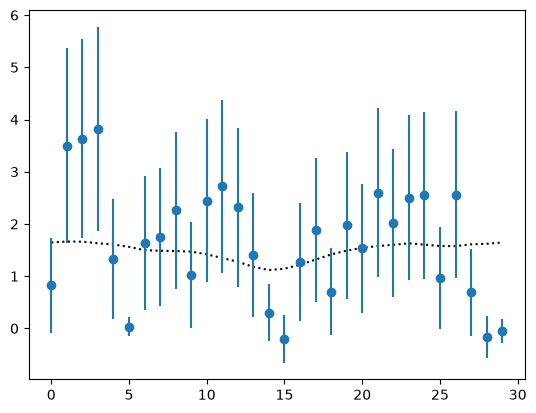

In [69]:
# Non-constant time series with red noise
n_non_constant_timeseries = 1000
spectrum = np.zeros(n_steps, dtype=np.complex128)
indices = np.arange(1, n_steps - 1)
spectrum[indices] = 1 / indices ** 2
all_spectra = spectrum[np.newaxis, :].repeat(n_non_constant_timeseries, axis=0)
all_spectra[:, 0] = 1# rng.uniform(low=1000, high=100000, size=n_constant_timeseries)
phases = np.exp(1j*rng.uniform(0, 2*np.pi, (n_non_constant_timeseries, n_steps)))
n = phases * all_spectra
x_true_rednoise = np.abs(np.fft.ifft(n, axis=1)) * 10 + mean_values[:, np.newaxis]
x_true_rednoise_err = np.sqrt(abs(x_true_rednoise))
x_rednoise = rng.normal(loc=x_true_rednoise, scale=x_true_rednoise_err)
x_rednoise_err = np.sqrt(abs(x_rednoise))

i = rng.integers(low=0, high=n_constant_timeseries)
plt.plot(np.arange(n_steps), x_true_rednoise[i], color="k", ls=":")
plt.errorbar(np.arange(n_steps), x_rednoise[i], yerr=x_rednoise_err[i], fmt='o')
plt.show()

In [70]:
# Combine the two sets of time series into one dataset
data = np.concatenate([x_const, x_rednoise], axis=0)
data_err = np.concatenate([x_const_err, x_rednoise_err], axis=0)

In [74]:
medians = np.median(data, axis=1)[:, np.newaxis]
normed_data = (data - medians) / data_err
# normed_data = data / medians
normed_data_err = data_err / np.abs(medians)

In [75]:
# randomly drop epochs
n_exp_missing = 2
n_missing = rng.poisson(lam=n_exp_missing, size=data.shape[0])
for i, inm in enumerate(n_missing):
    if inm > 0:
        missing_indices = rng.choice(np.arange(n_steps), size=inm, replace=False)
        normed_data[i, missing_indices] = np.nan
        normed_data_err[i, missing_indices] = np.nan

Training...
 [ 50000 / 50000 ] 100% - 0:00:00 left 
 quantization error: 6.090292795185081

...ready!


/var/folders/jx/f91vgd9j6l70d4mywt8tk84c0000gp/T/ipykernel_56475/2481421122.py:14: RuntimeWarning: Mean of empty slice
  ax.plot(np.nanmean(win_map[position], axis=0))
/Users/jannisnecker/opt/miniconda3/envs/minisom/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:1593: RuntimeWarning: All-NaN slice encountered
  return fnb._ureduce(a,


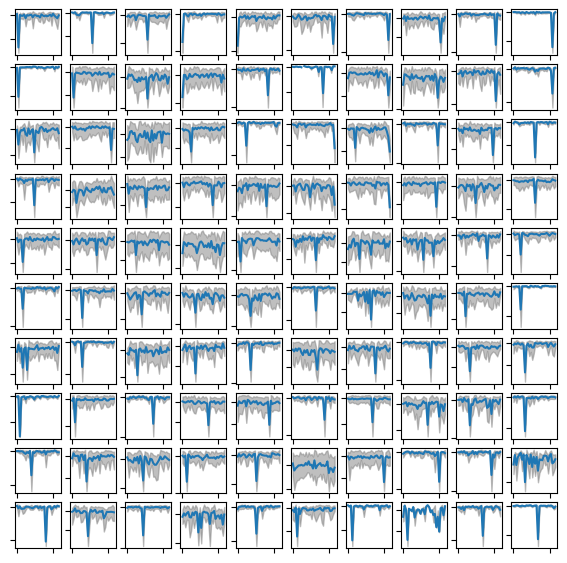

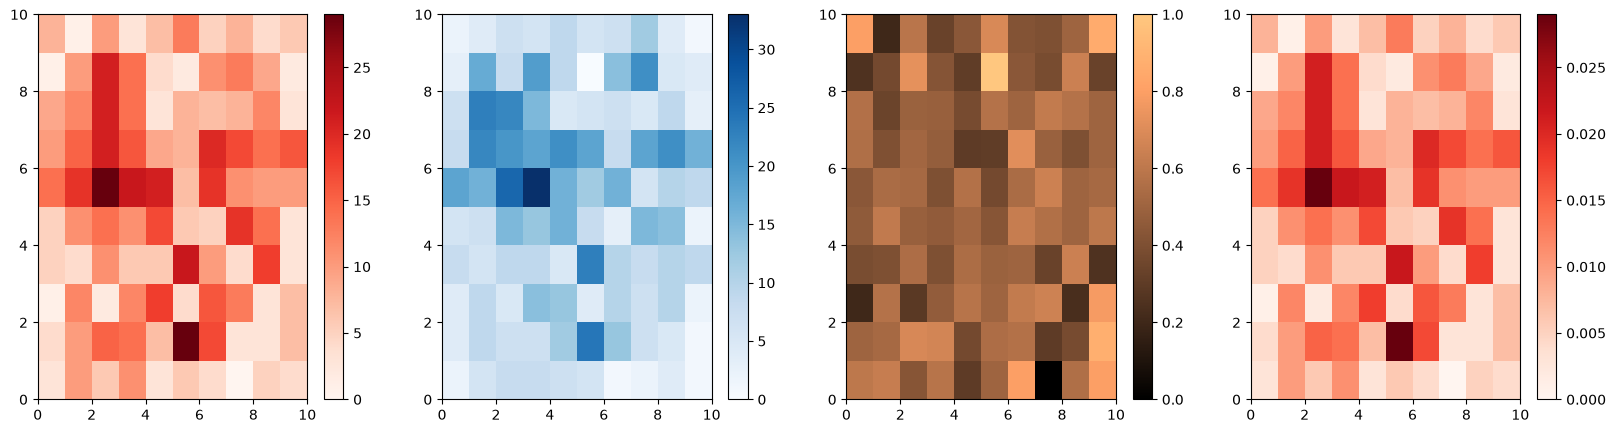

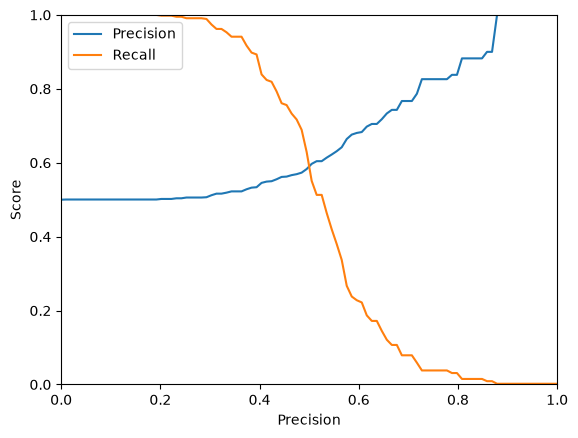

In [76]:
# Train a self-organizing map on the time series data
somsize = (10, 10)
som = MiniSom(*somsize, n_steps, sigma=1.0, learning_rate=0.5, random_seed=42)
som.pca_weights_init(normed_data)
print("Training...")
som.train_batch(normed_data, 50000, verbose=True)  # random training
print("\n...ready!")

win_map = som.win_map(normed_data)

fig, axs = plt.subplots(*somsize, figsize=(7, 7))
for position in win_map.keys():
    ax = axs[somsize[0] - 1 -position[0], position[1]]
    ax.plot(np.nanmean(win_map[position], axis=0))
    ax.fill_between(np.arange(n_steps), *np.nanquantile(win_map[position], [0.05, 0.95], axis=0), color='gray', alpha=.5)
    ax.xaxis.set_ticklabels([])
    ax.yaxis.set_ticklabels([])
plt.show()

constants_map = np.zeros(somsize)
for d in normed_data[:n_constant_timeseries]:
    w = som.winner(d)
    constants_map[w] += 1

rednoise_map = np.zeros(somsize)
for d in normed_data[n_constant_timeseries:]:
    w = som.winner(d)
    rednoise_map[w] += 1

purity_map = rednoise_map / (constants_map + rednoise_map)
recall_map = rednoise_map / rednoise_map.sum()

fig, axs = plt.subplots(ncols=4, figsize=(20, 5))
for cmap, pmap, ax in zip(["Reds", "Blues", 'copper', 'Reds'], [rednoise_map, constants_map, purity_map, recall_map], axs):
    mesh = ax.pcolormesh(pmap, cmap=cmap)  # plotting the distance map as background
    fig.colorbar(mesh, ax=ax)
plt.show()

rednoise = rednoise_map.flatten()
constants = constants_map.flatten()
probs = purity_map.flatten()

recall = []
precision = []
xx = np.linspace(0, 1, 100)
for i in xx:
    m = probs >= i
    precision.append(rednoise[m].sum() / (rednoise[m].sum() + constants[m].sum()))
    recall.append(rednoise[m].sum() / rednoise.sum())

fig, ax = plt.subplots()
ax.plot(xx, precision, label="Precision")
ax.plot(xx, recall, label="Recall")
ax.set_xlabel("Precision")
ax.set_ylabel("Score")
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.legend()
plt.show()


In [27]:
# Train a self-organizing map on the time series data
somsize = (10, 10)
som = MiniSom(*somsize, n_steps, sigma=1.0, learning_rate=0.5, random_seed=42)
som.pca_weights_init(normed_data)
print("Training...")
som.train_batch(normed_data, 50000, verbose=True, x_err=normed_data_err)  # random training
print("\n...ready!")

win_map = som.win_map(normed_data, data_err=normed_data_err)

fig, axs = plt.subplots(*somsize, figsize=(7, 7))
for position in win_map.keys():
    ax = axs[somsize[0] - 1 -position[0], position[1]]
    ax.plot(np.nanmean(win_map[position], axis=0))
    ax.fill_between(np.arange(n_steps), *np.nanquantile(win_map[position], [0.05, 0.95], axis=0), color='gray', alpha=.5)
    ax.xaxis.set_ticklabels([])
    ax.yaxis.set_ticklabels([])
plt.show()

constants_map = np.zeros(somsize)
for i in range(n_constant_timeseries):
    w = som.winner(normed_data[i], normed_data_err[i])
    constants_map[w] += 1

rednoise_map = np.zeros(somsize)
for i in range(n_constant_timeseries, n_constant_timeseries + n_non_constant_timeseries):
    w = som.winner(normed_data[i], normed_data_err[i])
    rednoise_map[w] += 1

purity_map = rednoise_map / (constants_map + rednoise_map)
recall_map = rednoise_map / rednoise_map.sum()

fig, axs = plt.subplots(ncols=4, figsize=(20, 5))
for cmap, pmap, ax in zip(["Reds", "Blues", 'copper', 'Reds'], [rednoise_map, constants_map, purity_map, recall_map], axs):
    mesh = ax.pcolormesh(pmap, cmap=cmap)  # plotting the distance map as background
    fig.colorbar(mesh, ax=ax)
plt.show()

Training...


TypeError: MiniSom.train_batch() got an unexpected keyword argument 'x_err'

In [9]:
m = normed_data_err <=0
normed_data[m]

array([], dtype=float64)

In [10]:
normed_data[m.any(axis=1)]

array([], shape=(0, 30), dtype=float64)

In [11]:
np.where(m.any(axis=1))

(array([], dtype=int64),)

In [12]:
x_const[646]

array([ 0.06167478, -0.03820361, -0.05331156, -0.096284  ,  0.3527787 ,
        0.05855333, -0.06634384, -0.03364753,  0.37805219, -0.02328466,
       -0.16305287,  0.02595593, -0.03863331, -0.15532102,  0.49346216,
       -0.43852474, -0.28945147,  0.03639422,  0.02945366, -0.00182646,
       -0.00807009, -0.06234079, -0.00645705,  0.17313116,  0.27496555,
       -0.11110357,  0.01415827,  0.17718752, -0.1225737 ,  0.17262186])

In [13]:
x_const_err[646]

array([0.24834408, 0.19545743, 0.23089297, 0.31029663, 0.59395177,
       0.24197795, 0.25757298, 0.18343262, 0.61485949, 0.15259313,
       0.40379805, 0.16110844, 0.19655357, 0.39410788, 0.70246862,
       0.662212  , 0.53800694, 0.19077269, 0.17162067, 0.0427371 ,
       0.0898337 , 0.24968137, 0.08035577, 0.41609033, 0.52437157,
       0.33332203, 0.11898853, 0.42093648, 0.35010527, 0.41547787])

In [14]:
data_err[646]

array([0.24834408, 0.19545743, 0.23089297, 0.31029663, 0.59395177,
       0.24197795, 0.25757298, 0.18343262, 0.61485949, 0.15259313,
       0.40379805, 0.16110844, 0.19655357, 0.39410788, 0.70246862,
       0.662212  , 0.53800694, 0.19077269, 0.17162067, 0.0427371 ,
       0.0898337 , 0.24968137, 0.08035577, 0.41609033, 0.52437157,
       0.33332203, 0.11898853, 0.42093648, 0.35010527, 0.41547787])

In [15]:
normed_data_err[]

SyntaxError: invalid syntax (2203339484.py, line 1)